# Patient 001 — Pipeline Results Interpretation

**Patient:** SRR9143066 (gastric cancer, primary tumor)  
**Normal:** SRR9143065 (Solid Tissue Normal, adjacent stomach tissue)  
**Run:** corrected STAR re-run (2026-06-23) — post Issue #370 (regtools anchor-outer coordinate fix) and Issue #212 (GTEx pan-tissue filter). Supersedes the pre-#370 HISAT2 run previously summarized here.  
**Data source:** Cloudflare R2 (`results/patient_001/`), after the GCP exit (Issue #854).  
**Analyst:** Scientist

---

> **Note:** patient_001 has a matched RNA-seq normal (adjacent stomach tissue). Junction filtering subtracts both (1) junctions shared with the matched normal and (2) junctions present in the GTEx pan-tissue reference, so the `tumor_exclusive` label here is doubly stringent.
>
> **Integrity correction:** the pre-#370 results previously summarized in this notebook (27,348 `tumor_exclusive` junctions, top candidate SQIPRTHSY) were artifacts of the anchor-outer coordinate bug — every junction was mis-placed, so exact GENCODE annotation matching silently failed and the entire unannotated pool leaked through as "novel". The corrected run yields **8** `tumor_exclusive` junctions. Audit tracked in Issue #663.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from r2_io import r2_read_tsv_cached

# Project data moved from GCS to Cloudflare R2 after the GCP exit (Issue #854).
# r2_io reads each TSV from the R2 bucket (credentials in the project-root .env)
# and caches it locally, so this notebook runs top-to-bottom reproducibly.
PREFIX = "results/patient_001"

print("Setup complete.")

Setup complete.


## 1. Run Summary

In [2]:
report = r2_read_tsv_cached(f"{PREFIX}/reports/report.tsv")
report

,patient_id,stage,metric,value,notes
0,patient_001,junction_filtering,unannotated,141,SRR9143066 (Primary Tumor)
1,patient_001,junction_filtering,tumor_exclusive,8,SRR9143066 (Primary Tumor)
2,patient_001,junction_filtering,normal_shared,94,SRR9143066 (Primary Tumor)
3,patient_001,junction_filtering,gtex_pantissue_shared,39,SRR9143066 (Primary Tumor)
4,patient_001,junction_filtering,junctions_extracted_total,131321,all tumor samples
5,patient_001,junction_filtering,junctions_mean_reads_filtered,99918,all tumor samples
6,patient_001,junction_filtering,junctions_annotated_discarded,31262,all tumor samples
7,patient_001,junction_filtering,junctions_unannotated_total,141,all tumor samples
8,patient_001,mhc_prediction,total_predictions,395,NaN
9,patient_001,mhc_prediction,non,356,presentation_percentile > 2.0%


## 2. Junction Analysis

### 2.1 Read-support distribution

The corrected post-#370 filtering leaves only **8 tumor_exclusive junctions**, so this is a small-n read-support profile rather than the right-skewed curve a full junction set would show. Tumor-exclusivity here is stringent: of 141 unannotated junctions, 94 are shared with the matched adjacent-normal stomach tissue and 39 with the GTEx pan-tissue reference, leaving 8. A dynamic per-file mean filter (keeps only junctions strictly above the per-sample mean read count) is also applied upstream.

Unannotated junctions:                  141
  ├─ normal_shared (removed):            94
  ├─ gtex_pantissue_shared (removed):    39
  └─ tumor_exclusive:                     8   ← carried forward to MHC prediction

Read support stats (tumor_exclusive):
count      8.000000
mean      60.625000
std       59.648823
min       20.000000
25%       21.750000
50%       28.000000
75%       77.750000
max      173.000000


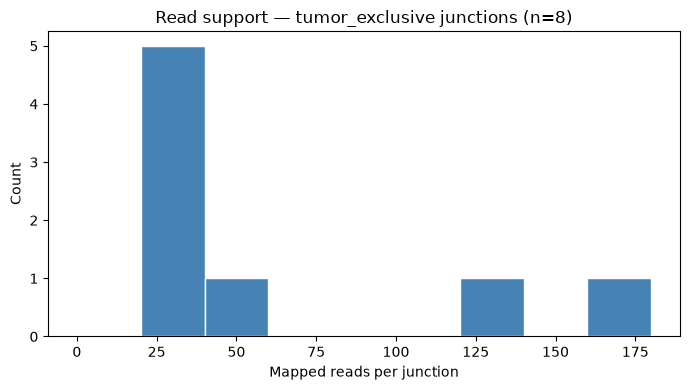

In [3]:
junctions = r2_read_tsv_cached(f"{PREFIX}/junctions/novel_junctions.tsv")

n_unannotated = len(junctions)
origin_counts = junctions["junction_origin"].value_counts()
n_normal_shared = int(origin_counts.get("normal_shared", 0))
n_gtex_shared = int(origin_counts.get("gtex_pantissue_shared", 0))
junctions = junctions[junctions["junction_origin"] == "tumor_exclusive"].reset_index(drop=True)
n_tumor_exclusive = len(junctions)

print(f"Unannotated junctions:                {n_unannotated:>5,}")
print(f"  ├─ normal_shared (removed):         {n_normal_shared:>5,}")
print(f"  ├─ gtex_pantissue_shared (removed): {n_gtex_shared:>5,}")
print(f"  └─ tumor_exclusive:                 {n_tumor_exclusive:>5,}   ← carried forward to MHC prediction")
print(f"\nRead support stats (tumor_exclusive):")
print(junctions["mapped_reads"].describe().to_string())

# Only 8 tumor_exclusive junctions survive the corrected (post-#370) filtering,
# so a single read-support histogram is the honest view (the former 100-bin
# log-scale + low-tail two-panel layout is meaningless at this n).
fig, ax = plt.subplots(figsize=(7, 4))
max_reads = int(junctions["mapped_reads"].max())
ax.hist(junctions["mapped_reads"], bins=range(0, max_reads + 20, 20),
        color="steelblue", edgecolor="white")
ax.set_xlabel("Mapped reads per junction")
ax.set_ylabel("Count")
ax.set_title(f"Read support — tumor_exclusive junctions (n={n_tumor_exclusive})")
plt.tight_layout()
plt.show()

## 3. Peptide Translation

How many junction-spanning peptides were translated, across which lengths? The pipeline extracts all peptides spanning the junction breakpoint across all three reading frames.

Total peptides: 395
Unique sequences: 395

Peptide length distribution:
peptide
8     113
9     133
10    149


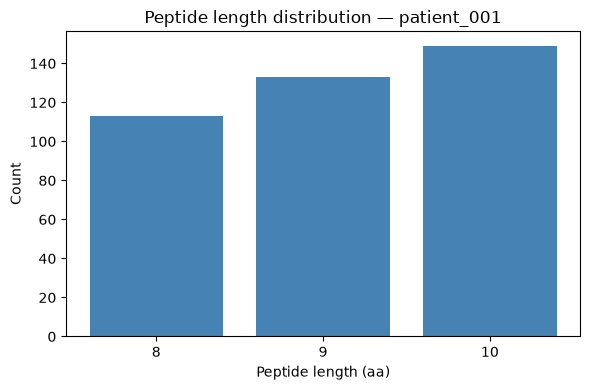

In [4]:
peptides = r2_read_tsv_cached(f"{PREFIX}/peptides/peptides_novel.tsv")
print(f"Total peptides: {len(peptides):,}")
print(f"Unique sequences: {peptides['peptide'].nunique():,}")

length_counts = peptides["peptide"].str.len().value_counts().sort_index()
print(f"\nPeptide length distribution:")
print(length_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(length_counts.index, length_counts.values, color="steelblue")
ax.set_xlabel("Peptide length (aa)")
ax.set_ylabel("Count")
ax.set_title("Peptide length distribution — patient_001")
ax.set_xticks(length_counts.index)
plt.tight_layout()
plt.show()

## 4. MHC Prediction Summary

### 4.1 Presentation class breakdown

How do peptide–allele predictions distribute across the strong (≤ 0.5th percentile), weak (≤ 2nd percentile), and non-presenter classes?

Total predictions loaded: 395

Presentation class breakdown:
presentation_class
strong     17
weak       22
non       356


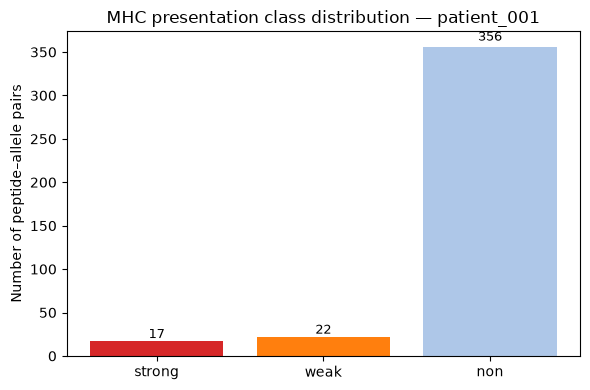

In [5]:
pres = r2_read_tsv_cached(f"{PREFIX}/predictions/mhc_presentation.tsv")
print(f"Total predictions loaded: {len(pres):,}")

class_counts = pres["presentation_class"].value_counts().reindex(["strong", "weak", "non"], fill_value=0)
print("\nPresentation class breakdown:")
print(class_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=["#d62728", "#ff7f0e", "#aec7e8"])
ax.set_ylabel("Number of peptide–allele pairs")
ax.set_title("MHC presentation class distribution — patient_001")
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 HLA allele dominance

Which alleles present the 17 strong-class peptides? patient_001's MHCflurry predictions ran against the tumor HLA calls: HLA-A\*31:01/A\*26:01, HLA-B\*15:63/B\*18:01, HLA-C\*07:01/C\*03:03. patient_002 showed strong HLA-C dominance (HLA-C\*01:02 / C\*07:01 ≈ 69% of strong presenters) — does it recapitulate here with different HLA-C alleles? (The cross-patient comparison is provisional: patient_002's stored numbers are still pre-#370 and await regeneration under Issue #212 / #378.)

Strong presenters per allele:
best_allele
HLA-C*03:03    9
HLA-C*07:01    3
HLA-A*31:01    3
HLA-B*18:01    1
HLA-B*15:63    1


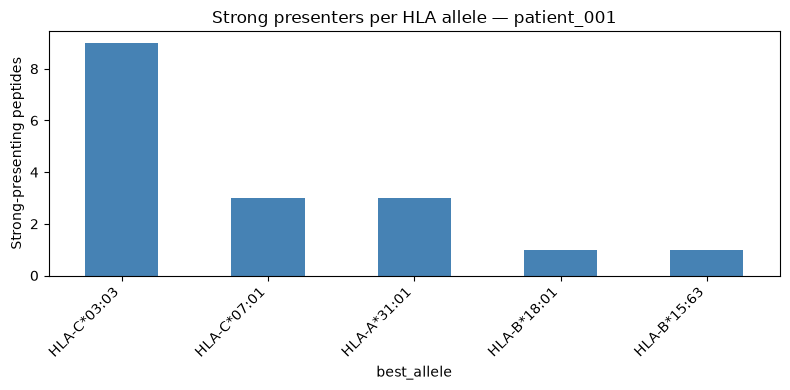

In [6]:
strong = pres[pres["presentation_class"] == "strong"]
allele_counts = strong["best_allele"].value_counts()
print("Strong presenters per allele:")
print(allele_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
allele_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Strong-presenting peptides")
ax.set_title("Strong presenters per HLA allele — patient_001")
ax.set_xticklabels(allele_counts.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Top Candidates

### 5.1 Top 20 by genotype presentation score

`genotype_presentation_score` (GPS) ranks candidates across the full patient HLA genotype — it rewards peptides presented by multiple alleles. This is the primary ranking used for prioritisation.

In [7]:
top20 = (pres.sort_values("genotype_presentation_score", ascending=False)
           .head(20)
           [["peptide", "best_allele", "ic50_nM", "presentation_percentile",
             "genotype_presentation_score", "n_strong_alleles", "presentation_class"]])
top20.reset_index(drop=True, inplace=True)
top20.index += 1
top20

,peptide,best_allele,ic50_nM,presentation_percentile,genotype_presentation_score,n_strong_alleles,presentation_class
1,SQVTRGLAM,HLA-B*15:63,64.726407,0.257283,0.942457,3,strong
2,RTVLQSLWFR,HLA-A*31:01,33.002758,0.127228,0.903006,1,strong
3,FFNVGPVLLR,HLA-A*31:01,125.430521,0.272717,0.862006,1,strong
4,VETSLLRSW,HLA-B*18:01,286.307118,0.277826,0.846683,1,strong
5,FFNVGPVL,HLA-C*03:03,100.609363,0.049511,0.836908,2,strong
6,FNVGPVLLR,HLA-A*31:01,72.024708,0.376902,0.823099,1,strong
7,FFNVGPVLL,HLA-C*03:03,57.636520,0.088804,0.815087,2,strong
8,ATGPWTRTV,HLA-C*03:03,209.175145,0.101386,0.799887,1,strong
9,FFFNVGPVL,HLA-C*03:03,69.090032,0.159620,0.742027,2,strong
10,FTGDTGSRY,HLA-A*26:01,118.876358,0.551168,0.735256,0,weak


### 5.2 Top candidate: SQVTRGLAM / HLA-B\*15:63

**IC50 = 64.7 nM | presentation_percentile = 0.257% | GPS = 0.9425 | n_strong_alleles = 3**

Key observations:
- IC50 ~65 nM is solidly in strong-presenter territory (threshold 500 nM; typical strong presenter < 50–100 nM).
- The 0.257th percentile is a strong call but not extreme — roughly 50× weaker than the old (buggy) top candidate's 0.0052%, which was an artifact of the inflated pre-#370 set.
- Presented as strong by **3 of 6 alleles** (GPS 0.9425) — genotype-broad, but no longer the near-ceiling GPS ≈ 1.0 the buggy run reported (which drew on 27,348 spurious junctions).
- **Junction of origin:** chr19:35699107–35932755 (minus strand). A sibling peptide from the same junction (YSQVTRGL, HLA-C\*03:03) also appears in the top 20, so this junction contributes two independent registered candidates.

**Caveat — low-complexity junctions in the candidate list:** ranks 3/5/6/7/9 (the FFNVGPVLLR / FFNVGPVL family) all derive from a single chr19:39227510 junction whose contig sequence is a long poly-T/poly-A run. Low-complexity regions are a known alignment-artifact risk; these candidates should be scrutinized (or filtered) before any downstream prioritization.

**Strength relative to patient_002:** patient_001 has a matched RNA-seq normal applied (plus the GTEx pan-tissue filter), so the originating junctions carry a stronger tumor-exclusivity claim than patient_002's WES-only normal. (Quantitative cross-patient comparison pending patient_002 regeneration.)

## 6. Genotype Presentation Score (GPS) — Validation

GPS = $1 - \prod_i (1 - w_i \cdot p_i)$ where $p_i$ is per-allele `presentation_score` and $w_i$ is locus weight (HLA-A/B = 1.0, HLA-C = 0.5; the weighting is approximate — MHCflurry applies its own locus-aware calibration internally during scoring). It estimates the probability that **at least one allele** in the patient's genotype presents the peptide. Primary ranking signal for the vaccine context; backed by a quality gate (`best_presentation_percentile ≤ 2%`).

Questions to answer empirically:
1. How is GPS distributed across all predictions — is it discriminating or does everyone score high?
2. Does GPS correlate with `n_strong_alleles` as expected?
3. Are there candidates with high GPS but poor best-allele percentile (the "inflation" edge case)?
4. Per-allele contribution: which alleles drive GPS most in this patient?

### 6.1 GPS distribution

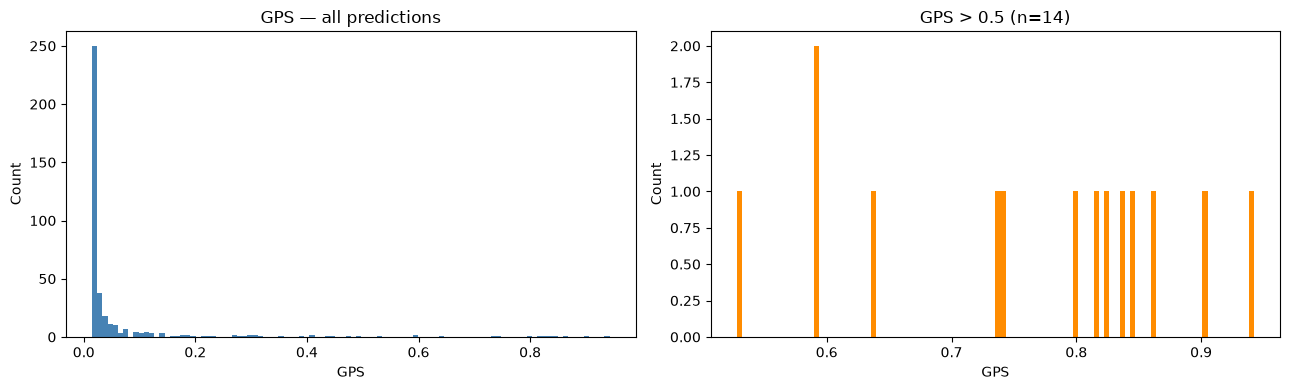


GPS summary stats:
count    395.000000
mean       0.072405
std        0.153894
min        0.014896
25%        0.016828
50%        0.019760
75%        0.037397
max        0.942457

GPS > 0.9: 2
GPS > 0.99: 0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full distribution
axes[0].hist(pres["genotype_presentation_score"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("GPS")
axes[0].set_ylabel("Count")
axes[0].set_title("GPS — all predictions")

# Zoom into the high end (> 0.5) where interesting candidates live
high = pres[pres["genotype_presentation_score"] > 0.5]
axes[1].hist(high["genotype_presentation_score"], bins=100, color="darkorange", edgecolor="none")
axes[1].set_xlabel("GPS")
axes[1].set_ylabel("Count")
axes[1].set_title(f"GPS > 0.5 (n={len(high):,})")

plt.tight_layout()
plt.show()

print(f"\nGPS summary stats:")
print(pres["genotype_presentation_score"].describe().to_string())
print(f"\nGPS > 0.9: {(pres['genotype_presentation_score'] > 0.9).sum():,}")
print(f"GPS > 0.99: {(pres['genotype_presentation_score'] > 0.99).sum():,}")

### 6.2 GPS vs n_strong_alleles — does breadth drive the score?

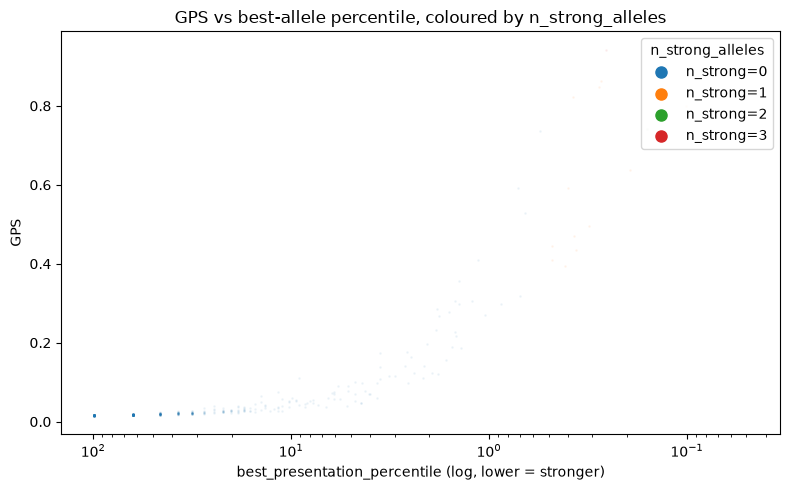

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for n, grp in pres.groupby("n_strong_alleles"):
    ax.scatter(grp["best_presentation_percentile"], grp["genotype_presentation_score"],
               alpha=0.05, s=1, label=f"n_strong={n}")

ax.set_xscale("log")
ax.set_xlabel("best_presentation_percentile (log, lower = stronger)")
ax.set_ylabel("GPS")
ax.set_title("GPS vs best-allele percentile, coloured by n_strong_alleles")
ax.invert_xaxis()
legend = ax.legend(markerscale=8, title="n_strong_alleles", loc="upper right")
for lh in legend.legend_handles:
    lh.set_alpha(1)
plt.tight_layout()
plt.show()

### 6.3 Inflation check — high GPS with no strong allele

The GPS-inflation edge case (GPS > 0.9 driven by allele breadth while no single allele clears the strong threshold) is what the current quality gate (`best_presentation_percentile ≤ 2%`) does not catch. With only 395 predictions in the corrected set, there are **zero** such cases here (vs 25 in the old buggy patient_001 set and 174 in patient_002) — at this n the edge case is essentially absent.

In [10]:
# Candidates with GPS > 0.9 but n_strong_alleles == 0.
# These are NOT caught by the current quality gate (best_presentation_percentile <= 2%) —
# their best_percentile is just above the strong threshold (0.5%), so GPS inflates from
# allele breadth rather than per-allele strength.
# patient_002 had 174 such cases; comparing here.
inflated = pres[(pres["genotype_presentation_score"] > 0.9) & (pres["n_strong_alleles"] == 0)]
print(f"GPS > 0.9 with n_strong_alleles = 0: {len(inflated):,}")
if len(inflated) > 0:
    print("\nTop 10 by GPS:")
    print(inflated.nlargest(10, "genotype_presentation_score")
          [["peptide", "best_allele", "best_presentation_percentile",
            "genotype_presentation_score", "n_strong_alleles"]].to_string())

GPS > 0.9 with n_strong_alleles = 0: 0


### 6.4 Per-allele contribution to GPS

     allele  median_pres_score_strong  pct_as_best_allele  median_percentile_strong
HLA-A*26:01                  0.021368            0.000000                 11.115788
HLA-A*31:01                  0.029840           17.647059                  8.269212
HLA-B*15:63                  0.074404            5.882353                  3.639185
HLA-B*18:01                  0.019513            5.882353                 12.187228
HLA-C*03:03                  0.697301           52.941176                  0.442609
HLA-C*07:01                  0.532302           17.647059                  0.753288


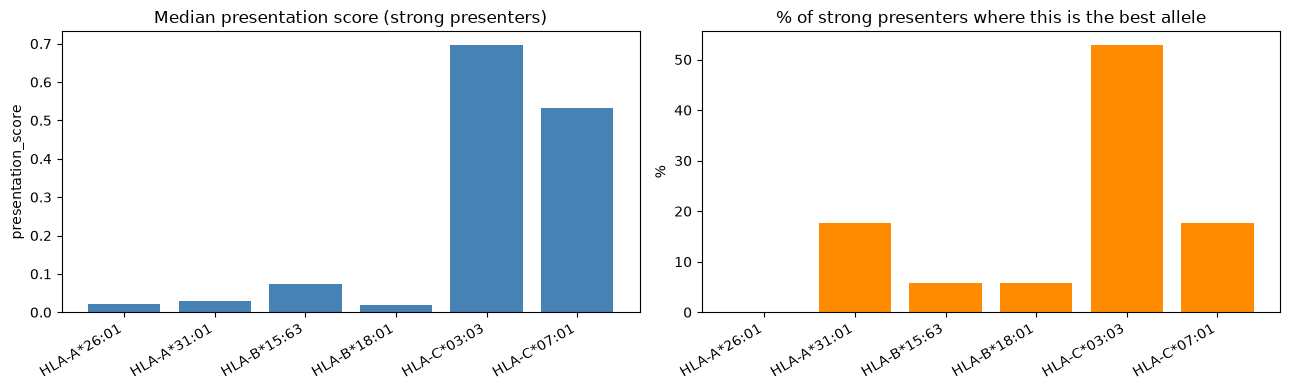

In [11]:
# Derive alleles from column names — works across patients without modification
alleles = sorted([c.replace("_presentation_score", "")
                  for c in pres.columns if c.endswith("_presentation_score")
                  and c.startswith("HLA-")])
score_cols = [f"{a}_presentation_score" for a in alleles]
pct_cols   = [f"{a}_presentation_percentile" for a in alleles]

strong = pres[pres["presentation_class"] == "strong"]

summary = pd.DataFrame({
    "allele": alleles,
    "median_pres_score_strong": [strong[c].median() for c in score_cols],
    "pct_as_best_allele": [
        (strong["best_allele"] == a).sum() / len(strong) * 100 for a in alleles
    ],
    "median_percentile_strong": [strong[c].median() for c in pct_cols],
})
print(summary.to_string(index=False))

x = range(len(summary))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(x, summary["median_pres_score_strong"], color="steelblue")
axes[0].set_title("Median presentation score (strong presenters)")
axes[0].set_ylabel("presentation_score")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(summary["allele"], rotation=30, ha="right")

axes[1].bar(x, summary["pct_as_best_allele"], color="darkorange")
axes[1].set_title("% of strong presenters where this is the best allele")
axes[1].set_ylabel("%")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(summary["allele"], rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 7. Scientific Summary & Open Questions

> **Integrity note:** this notebook was regenerated from the corrected STAR re-run (2026-06-23) after the Issue #370 anchor-outer coordinate bug invalidated all pre-#370 junction sets. The previously-reported figures (27,348 tumor_exclusive junctions, 1.28M predictions, top candidate SQIPRTHSY / HLA-C\*07:01) were artifacts and have been replaced throughout. Audit tracked in Issue #663.

### Key findings

1. **Tumor-exclusive set collapses to 8 junctions** — of 141 unannotated junctions, 94 are shared with the matched adjacent-normal and 39 with the GTEx pan-tissue reference, leaving 8 tumor_exclusive (vs the spurious 27,348 in the pre-#370 set). This is the headline correctness change: the buggy set leaked the entire unannotated pool because mis-placed coordinates failed exact GENCODE matching.
2. **Top candidate SQVTRGLAM / HLA-B\*15:63** — IC50 64.7 nM, percentile 0.257%, GPS 0.9425, strong across 3/6 alleles. A genuine strong presenter with realistic (non-ceiling) scores, unlike the buggy run's GPS ≈ 0.9999.
3. **HLA-C dominance recapitulated** — 12 of 17 strong presenters (70.6%) are HLA-C (C\*03:03 = 9, C\*07:01 = 3); HLA-C\*03:03 alone is the best allele for 52.9% of strong presenters, with median presentation_score 0.70. This closely matches patient_002's ~69% HLA-C share despite different HLA-C alleles — strengthening the hypothesis that HLA-C is intrinsically more promiscuous and/or that MHCflurry's percentile calibration is uniformly looser for HLA-C. (patient_002 comparison provisional — pre-#370.)
4. **The top-GPS candidate is HLA-B, not HLA-C** — although HLA-C dominates by presenter count, the single best-GPS peptide sits on HLA-B\*15:63. Breadth (GPS) and per-allele dominance pick different "winners" here.
5. **HLA-A\*31:01 active, HLA-A\*26:01 a passenger** — A\*31:01 is the best allele for 17.6% of strong presenters (median percentile 8.3), while A\*26:01 is best for none (median percentile 11.1) — every genotype has a quiet allele.
6. **GPS no longer near-ceiling** — max GPS 0.9425 (vs 0.9999 in the buggy run); only 2 of 395 predictions exceed 0.9 and none exceed 0.99. The complementary-probability formula behaves sensibly, but the small candidate set limits what the distribution can say.
7. **No GPS-inflation edge cases** — zero candidates with GPS > 0.9 and n_strong_alleles = 0 (vs 25 before), unsurprising at n=395.
8. **Low-complexity junction caveat** — 5 of the top 20 candidates derive from a single chr19:39227510 poly-T/poly-A junction (the FFNVGPVLLR family); these warrant scrutiny as possible alignment artifacts before prioritization.

### Open questions / next steps

- **patient_002 regeneration** — all cross-patient comparisons here are provisional until patient_002 is re-run under the corrected pipeline (Issue #212 AC #6 / #378). The patient_002 notebook still carries pre-#370 numbers and must be regenerated before any side-by-side.
- **Low-complexity / artifact filter** — the poly-T chr19:39227510 candidates suggest a sequence-complexity flag or filter may be warranted upstream; worth a scoped issue if it recurs across patients.
- **Statistical power at n=8** — with 8 tumor_exclusive junctions and 395 predictions, the GPS-distribution, dominance, and inflation analyses are descriptive only. The live scientific question is now whether the 8 survive orthogonal scrutiny (read support, sequence complexity, GENCODE adjacency), not population-level distribution claims.
- **HLA-C calibration** — the persistence of HLA-C dominance across two patients with different HLA-C alleles continues to point at a calibration question; cross-validating top HLA-C candidates against an orthogonal predictor remains a useful check.